In [1]:
import zipfile

zip_path = "/content/sagardrishti-ai.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/project")

In [2]:
import zipfile

zip_path = "/content/sagardrishti-ai.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/project")

In [3]:
import os

for root, dirs, files in os.walk("/content/project"):
    print(root, files)

/content/project []
/content/project/sagardrishti-ai ['README.md', 'requirements.txt']
/content/project/sagardrishti-ai/{oil_spill_detection,vessel_attribution,trajectory_prediction,data,notebooks} []
/content/project/sagardrishti-ai/oil_spill_detection ['infer.py', 'train.py', 'dataset.py', 'model.py']
/content/project/sagardrishti-ai/data ['download_datasets.md', 'generate_synthetic_ais.py']
/content/project/sagardrishti-ai/trajectory_prediction ['drift_model.py', 'demo.py']
/content/project/sagardrishti-ai/vessel_attribution ['attribution_engine.py', 'demo.py']


In [4]:
!pip install -r /content/project/requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '/content/project/requirements.txt'


In [5]:
import os

for root, dirs, files in os.walk("/content/project"):
    print("\n📁", root)
    for file in files:
        print("   ", file)


📁 /content/project

📁 /content/project/sagardrishti-ai
    README.md
    requirements.txt

📁 /content/project/sagardrishti-ai/{oil_spill_detection,vessel_attribution,trajectory_prediction,data,notebooks}

📁 /content/project/sagardrishti-ai/oil_spill_detection
    infer.py
    train.py
    dataset.py
    model.py

📁 /content/project/sagardrishti-ai/data
    download_datasets.md
    generate_synthetic_ais.py

📁 /content/project/sagardrishti-ai/trajectory_prediction
    drift_model.py
    demo.py

📁 /content/project/sagardrishti-ai/vessel_attribution
    attribution_engine.py
    demo.py


In [6]:
%cd /content/project/sagardrishti-ai

/content/project/sagardrishti-ai


In [7]:
!pip install -r requirements.txt

In [8]:
!ls

data
oil_spill_detection
{oil_spill_detection,vessel_attribution,trajectory_prediction,data,notebooks}
README.md
requirements.txt
trajectory_prediction
vessel_attribution


In [9]:
!cat README.md

# SAGARDRISHTI — AI/ML Core (Team Piranhas, SIH 2026, PS 26143)

Starter implementation of the three AI/ML components described in the pitch deck:

1. **Oil spill detection** — U-Net semantic segmentation on Sentinel-1 SAR imagery
2. **Vessel attribution engine** — percentage-based scoring of which vessel likely caused a spill, using AIS data
3. **Trajectory / drift prediction** — simple Lagrangian particle drift model driven by wind + current data

This is a *working baseline*, not the final production system — the goal is something you can run,
demo, and iterate on before the hackathon.

## Folder structure

```
sagardrishti-ai/
├── data/
│   ├── download_datasets.md      # where to get real data
│   └── generate_synthetic_ais.py # makes fake AIS + spill data so you can test NOW
├── oil_spill_detection/
│   ├── dataset.py                # PyTorch Dataset for SAR image + mask pairs
│   ├── model.py                  # U-Net architecture
│   ├── train.py                  # training loop

In [10]:
!python data/generate_synthetic_ais.py

Wrote 576 AIS pings for 12 vessels -> /content/project/sagardrishti-ai/data/synthetic/ais_tracks.csv
Wrote spill event -> /content/project/sagardrishti-ai/data/synthetic/spill_event.json
(Ground-truth culprit for validation: MMSI 200000001 — don't use this field as a feature!)


In [11]:
!find data -maxdepth 2 -type f

data/synthetic/ais_tracks.csv
data/synthetic/spill_event.json
data/download_datasets.md
data/generate_synthetic_ais.py


In [12]:
!python vessel_attribution/demo.py


Spill SPILL_0001 at (13.1644, 80.3194), detected 2026-08-01T14:00:00

=== Vessel Attribution (ranked) ===
MMSI 200000001 (VESSEL_200000001, Tanker): 100.0% attribution
    - Closest approach 1.15 km from spill (proximity score 0.94).
    - Closest approach was 0.00 h from detection time (temporal score 1.00).
    - Course-over-ground consistent with heading toward spill point (heading score 0.72).
    - Vessel type 'Tanker' has baseline risk prior 1.00.

=== Ruled Out (negative evidence) — 11 vessels ===
MMSI 200000002 (VESSEL_200000002, Cargo): Closest recorded position was 29.3 km from the spill (beyond the 15 km plausibility radius).; Nearest approach was 12.5 h from detection time (beyond the 6 h plausibility window).
MMSI 200000003 (VESSEL_200000003, Tanker): Closest recorded position was 32.8 km from the spill (beyond the 15 km plausibility radius).; Nearest approach was 12.0 h from detection time (beyond the 6 h plausibility window).
MMSI 200000004 (VESSEL_200000004, Fishing): 

In [13]:
!python trajectory_prediction/demo.py

Spill origin: (13.1644, 80.3194)
Predicted 24h footprint (lat_min,lat_max,lon_min,lon_max): (np.float64(13.1333), np.float64(13.1562), np.float64(80.4761), np.float64(80.4966))
Predicted 48h footprint: (np.float64(13.1122), np.float64(13.1442), np.float64(80.6404), np.float64(80.672))
Saved plot to /content/project/sagardrishti-ai/trajectory_prediction/trajectory_plot.png


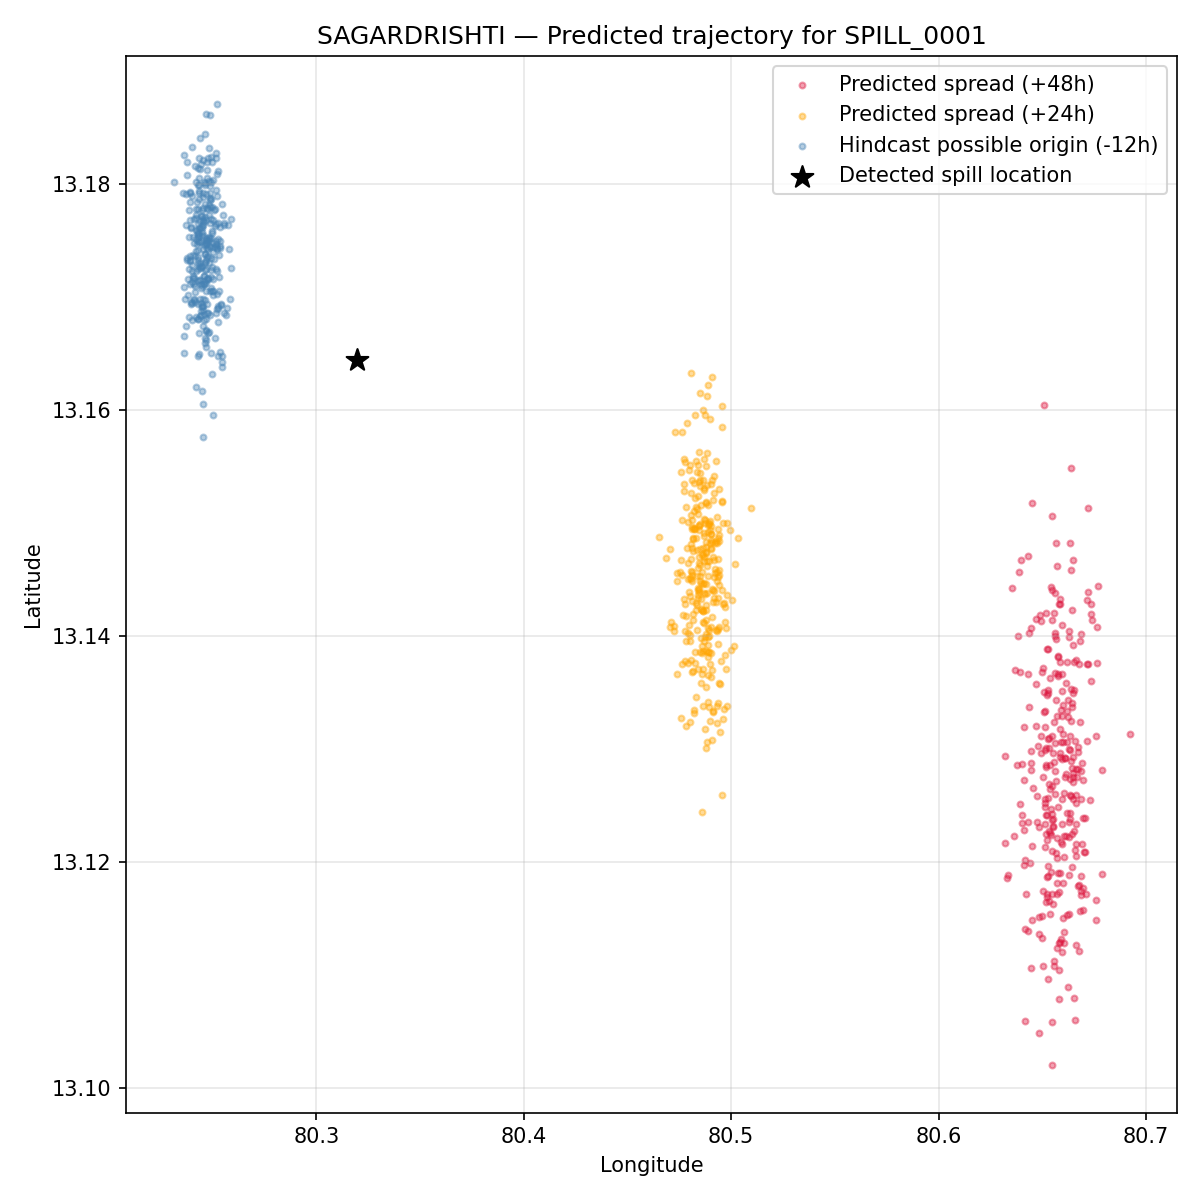

In [14]:
from IPython.display import Image, display

display(Image(filename="trajectory_prediction/trajectory_plot.png"))

In [15]:
!cat oil_spill_detection/dataset.py

"""
PyTorch Dataset for oil spill segmentation.

Expects:
    data_dir/
        images/  *.png or *.jpg   (SAR image chips, grayscale or RGB)
        masks/   *.png            (binary mask, same base filename, white=oil/255, black=background/0)

This matches the layout of the common Kaggle "oil spill detection" SAR datasets.
"""
import os
import glob
import numpy as np
import cv2
from torch.utils.data import Dataset


class OilSpillDataset(Dataset):
    def __init__(self, data_dir, img_size=256, augment=False):
        self.img_dir = os.path.join(data_dir, "images")
        self.mask_dir = os.path.join(data_dir, "masks")
        self.img_size = img_size
        self.augment = augment

        self.image_paths = sorted(
            glob.glob(os.path.join(self.img_dir, "*.png"))
            + glob.glob(os.path.join(self.img_dir, "*.jpg"))
        )
        if len(self.image_paths) == 0:
            raise FileNotFoundError(
                f"No images found in {self.img_dir}. "
          

In [16]:
!cat oil_spill_detection/train.py

"""
Train the U-Net oil spill segmentation model.

Usage:
    python oil_spill_detection/train.py --data_dir data/spill_dataset --epochs 20 --batch_size 8
"""
import argparse
import os
import sys

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

sys.path.append(os.path.dirname(__file__))
from dataset import OilSpillDataset
from model import UNet


def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def combined_loss(logits, targets):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, targets)
    dl = dice_loss(logits, targets)
    return bce + dl


def train(args):
    device = torch.device("cuda" if torch.cuda.is_availab

In [17]:
!wget -O /content/Radar_data.rar "https://zenodo.org/records/4672426/files/Radar_data.rar?download=1"

--2026-09-15 15:46:12--  https://zenodo.org/records/4672426/files/Radar_data.rar?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 487624870 (465M) [application/octet-stream]
Saving to: ‘/content/Radar_data.rar’

/content/Radar_data 100%[===================>] 465.04M  6.20MB/s    in 1m 55s  

2026-09-15 15:48:08 (4.03 MB/s) - ‘/content/Radar_data.rar’ saved [487624870/487624870]



In [18]:
!apt-get -qq update
!apt-get -qq install unrar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [19]:
!mkdir -p /content/oil_spill_raw
!unrar x -o+ /content/Radar_data.rar /content/oil_spill_raw/


UNRAR 7.00 freeware      Copyright (c) 1993-2024 Alexander Roshal


Extracting from /content/Radar_data.rar

Creating    /content/oil_spill_raw/test                               OK
Creating    /content/oil_spill_raw/test/images                        OK
Extracting  /content/oil_spill_raw/test/images/2018_09_26.tif              0%  1%  2%  3%  4%  5%  6%  OK 
Extracting  /content/oil_spill_raw/test/images/2018_12_19_d.tif            7%  8%  OK 
Extracting  /content/oil_spill_raw/test/images/2018_12_19_e.tif            8%  9% 10% 11% 12%  OK 
Extracting  /content/oil_spill_raw/test/images/2018_12_19_f_.tif          13% 14% 15% 16%  OK 
Extracting  /content/oil_spill_raw/test/images/20191015.tif               17% 18% 19% 20% 21%  OK 
Extracting  /content/oil_spill_raw/test/images/20200224_b.tif             22% 23%  OK 
Extracting  /content/oil_spill_raw/test/

In [20]:
!find /content/oil_spill_raw -maxdepth 3 -type f | head -50

/content/oil_spill_raw/test/masks/20200319b.tif
/content/oil_spill_raw/test/masks/2018_12_19_e.tif
/content/oil_spill_raw/test/masks/20200224_b.tif
/content/oil_spill_raw/test/masks/2018_12_19_f_.tif
/content/oil_spill_raw/test/masks/2018_09_26.tif
/content/oil_spill_raw/test/masks/20191015.tif
/content/oil_spill_raw/test/masks/2018_12_19_d.tif
/content/oil_spill_raw/test/images/20200319b.tif
/content/oil_spill_raw/test/images/2018_12_19_e.tif
/content/oil_spill_raw/test/images/20200224_b.tif
/content/oil_spill_raw/test/images/2018_12_19_f_.tif
/content/oil_spill_raw/test/images/2018_09_26.tif
/content/oil_spill_raw/test/images/20191015.tif
/content/oil_spill_raw/test/images/2018_12_19_d.tif
/content/oil_spill_raw/train/dataframe_val_dataset_256_90.csv
/content/oil_spill_raw/train/masks/2018_12_19_b.tif
/content/oil_spill_raw/train/masks/2018_12_07_b.tif
/content/oil_spill_raw/train/masks/20200224.tif
/content/oil_spill_raw/train/masks/20200822.tif
/content/oil_spill_raw/train/masks/20

In [21]:
import os
import cv2

# Source folders
train_images = "/content/oil_spill_raw/train/images"
train_masks = "/content/oil_spill_raw/train/masks"

test_images = "/content/oil_spill_raw/test/images"
test_masks = "/content/oil_spill_raw/test/masks"

# Destination folders for Claude's U-Net
base = "/content/project/sagardrishti-ai/data/spill_dataset"

os.makedirs(f"{base}/images", exist_ok=True)
os.makedirs(f"{base}/masks", exist_ok=True)

# Convert TIFF → PNG
def convert_folder(image_dir, mask_dir, output_dir):
    count = 0

    for filename in sorted(os.listdir(image_dir)):
        if not filename.lower().endswith(".tif"):
            continue

        image_path = os.path.join(image_dir, filename)
        mask_path = os.path.join(mask_dir, filename)

        if not os.path.exists(mask_path):
            print("Missing mask:", filename)
            continue

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            print("Could not read:", filename)
            continue

        name = os.path.splitext(filename)[0]

        cv2.imwrite(
            os.path.join(output_dir, "images", name + ".png"),
            image
        )

        cv2.imwrite(
            os.path.join(output_dir, "masks", name + ".png"),
            mask
        )

        count += 1

    return count

train_count = convert_folder(
    train_images, train_masks, base
)

test_count = convert_folder(
    test_images, test_masks, base
)

print(f"Converted {train_count} training image-mask pairs")
print(f"Converted {test_count} test image-mask pairs")
print(f"\nDataset created at: {base}")

Could not read: 2018_08_21_.tif
Could not read: 2018_09_14_.tif
Could not read: 2018_12_07.tif
Could not read: 2018_12_07_b.tif
Could not read: 2018_12_19.tif
Could not read: 2018_12_19_b.tif
Could not read: 2018_12_31_b.tif
Could not read: 20190816.tif
Could not read: 20190908.tif
Could not read: 20200224.tif
Could not read: 20200307.tif
Could not read: 20200319.tif
Could not read: 20200331.tif
Could not read: 20200822.tif
Could not read: 2018_09_26.tif
Could not read: 2018_12_19_d.tif
Could not read: 2018_12_19_e.tif
Could not read: 2018_12_19_f_.tif
Could not read: 20191015.tif
Could not read: 20200224_b.tif
Could not read: 20200319b.tif
Converted 0 training image-mask pairs
Converted 0 test image-mask pairs

Dataset created at: /content/project/sagardrishti-ai/data/spill_dataset


In [22]:
!find /content/project/sagardrishti-ai/data/spill_dataset -type f | head -30

In [23]:
import os

images = os.listdir("/content/project/sagardrishti-ai/data/spill_dataset/images")
masks = os.listdir("/content/project/sagardrishti-ai/data/spill_dataset/masks")

print("Images:", len(images))
print("Masks:", len(masks))
print("Matching:", set(images) == set(masks))

Images: 0
Masks: 0
Matching: True


In [24]:
!pip install -q rasterio

In [25]:
import rasterio

sample_path = "/content/oil_spill_raw/train/images/2018_12_19_b.tif"

with rasterio.open(sample_path) as src:
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)

    image = src.read(1)

print("Image shape:", image.shape)
print("Min:", image.min())
print("Max:", image.max())

Width: 4640
Height: 2165
Bands: 1
Dtype: ('float32',)
CRS: EPSG:32616
Image shape: (2165, 4640)
Min: -30.585346
Max: 27.417784


In [26]:
import os
import numpy as np
import rasterio
from PIL import Image

raw_base = "/content/oil_spill_raw"
output_base = "/content/project/sagardrishti-ai/data"

train_out = os.path.join(output_base, "spill_dataset_train")
test_out = os.path.join(output_base, "spill_dataset_test")

for base in [train_out, test_out]:
    os.makedirs(os.path.join(base, "images"), exist_ok=True)
    os.makedirs(os.path.join(base, "masks"), exist_ok=True)


def normalize_image(image):
    """
    Convert Sentinel-1 float32 SAR values to 8-bit PNG
    while preserving relative intensity information.
    """
    image = image.astype(np.float32)

    # Robust percentile scaling
    low, high = np.percentile(image, [1, 99])

    image = np.clip(image, low, high)
    image = (image - low) / (high - low + 1e-8)

    return (image * 255).astype(np.uint8)


def convert_dataset(split):
    image_dir = os.path.join(raw_base, split, "images")
    mask_dir = os.path.join(raw_base, split, "masks")
    output_dir = train_out if split == "train" else test_out

    count = 0

    for filename in sorted(os.listdir(image_dir)):

        if not filename.lower().endswith(".tif"):
            continue

        image_path = os.path.join(image_dir, filename)
        mask_path = os.path.join(mask_dir, filename)

        if not os.path.exists(mask_path):
            print("Missing mask:", filename)
            continue

        # Read SAR image using rasterio
        with rasterio.open(image_path) as src:
            image = src.read(1)

        # Read mask using rasterio
        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        # Convert SAR image to 8-bit
        image_8bit = normalize_image(image)

        # Convert mask to binary 0/255
        mask_binary = np.where(mask > 0, 255, 0).astype(np.uint8)

        name = os.path.splitext(filename)[0]

        Image.fromarray(image_8bit).save(
            os.path.join(output_dir, "images", name + ".png")
        )

        Image.fromarray(mask_binary).save(
            os.path.join(output_dir, "masks", name + ".png")
        )

        count += 1

    return count


train_count = convert_dataset("train")
test_count = convert_dataset("test")

print("\n==============================")
print(f"Converted training pairs: {train_count}")
print(f"Converted test pairs:     {test_count}")
print("==============================")

print("\nTraining dataset:")
print(os.listdir(os.path.join(train_out, "images")))

print("\nTest dataset:")
print(os.listdir(os.path.join(test_out, "images")))


Converted training pairs: 14
Converted test pairs:     7

Training dataset:
['2018_12_19_b.png', '2018_12_07.png', '2018_09_14_.png', '20200822.png', '20200331.png', '20200319.png', '20200307.png', '2018_08_21_.png', '2018_12_07_b.png', '20190816.png', '2018_12_31_b.png', '20200224.png', '20190908.png', '2018_12_19.png']

Test dataset:
['20200224_b.png', '2018_12_19_e.png', '20200319b.png', '2018_12_19_d.png', '2018_09_26.png', '2018_12_19_f_.png', '20191015.png']


In [27]:
import os

train_images = os.listdir(
    "/content/project/sagardrishti-ai/data/spill_dataset_train/images"
)

train_masks = os.listdir(
    "/content/project/sagardrishti-ai/data/spill_dataset_train/masks"
)

test_images = os.listdir(
    "/content/project/sagardrishti-ai/data/spill_dataset_test/images"
)

test_masks = os.listdir(
    "/content/project/sagardrishti-ai/data/spill_dataset_test/masks"
)

print("TRAIN")
print("Images:", len(train_images))
print("Masks:", len(train_masks))
print("Matching:", set(train_images) == set(train_masks))

print("\nTEST")
print("Images:", len(test_images))
print("Masks:", len(test_masks))
print("Matching:", set(test_images) == set(test_masks))

TRAIN
Images: 14
Masks: 14
Matching: True

TEST
Images: 7
Masks: 7
Matching: True


In [28]:
%cd /content/project/sagardrishti-ai

!python oil_spill_detection/train.py \
    --data_dir data/spill_dataset_train \
    --epochs 20 \
    --batch_size 2 \
    --img_size 256 \
    --base_channels 32 \
    --checkpoint_dir checkpoints

/content/project/sagardrishti-ai
Using device: cpu
Epoch 1/20 [train]: 100% 6/6 [00:26<00:00,  4.45s/it]
Epoch 1: train_loss=1.7244  val_loss=1.7492
  -> saved new best checkpoint to checkpoints/unet_best.pt
Epoch 2/20 [train]: 100% 6/6 [00:26<00:00,  4.35s/it]
Epoch 2: train_loss=1.5621  val_loss=1.7289
  -> saved new best checkpoint to checkpoints/unet_best.pt
Epoch 3/20 [train]: 100% 6/6 [00:24<00:00,  4.16s/it]
Epoch 3: train_loss=1.4785  val_loss=1.5127
  -> saved new best checkpoint to checkpoints/unet_best.pt
Epoch 4/20 [train]: 100% 6/6 [00:24<00:00,  4.12s/it]
Epoch 4: train_loss=1.4232  val_loss=1.4156
  -> saved new best checkpoint to checkpoints/unet_best.pt
Epoch 5/20 [train]: 100% 6/6 [00:24<00:00,  4.15s/it]
Epoch 5: train_loss=1.3846  val_loss=1.3840
  -> saved new best checkpoint to checkpoints/unet_best.pt
Epoch 6/20 [train]: 100% 6/6 [00:25<00:00,  4.18s/it]
Epoch 6: train_loss=1.3540  val_loss=1.3648
  -> saved new best checkpoint to checkpoints/unet_best.pt
Epoch 7

In [29]:
%%writefile oil_spill_detection/evaluate.py

import os
import sys
import torch
import numpy as np
from torch.utils.data import DataLoader

sys.path.append(os.path.dirname(__file__))

from dataset import OilSpillDataset
from model import UNet


def calculate_metrics(pred, target):
    pred = pred.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()

    dice = (2 * intersection) / (
        pred.sum() + target.sum() + 1e-8
    )

    iou = intersection / (union + 1e-8)

    return dice, iou


def evaluate():

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print("Using device:", device)

    data_dir = "data/spill_dataset_test"
    checkpoint_path = "checkpoints/unet_best.pt"

    dataset = OilSpillDataset(
        data_dir,
        img_size=256,
        augment=False
    )

    loader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=False
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model = UNet(
        base_channels=checkpoint["base_channels"]
    ).to(device)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    dice_scores = []
    iou_scores = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            logits = model(images)

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities > 0.5
            ).cpu().numpy()

            targets = masks.numpy()

            dice, iou = calculate_metrics(
                predictions[0, 0],
                targets[0, 0]
            )

            dice_scores.append(dice)
            iou_scores.append(iou)

    print("\n==============================")
    print("TEST RESULTS")
    print("==============================")

    print(
        f"Mean Dice: {np.mean(dice_scores):.4f}"
    )

    print(
        f"Mean IoU:  {np.mean(iou_scores):.4f}"
    )

    print("\nIndividual images:")

    for i, (dice, iou) in enumerate(
        zip(dice_scores, iou_scores), 1
    ):
        print(
            f"Image {i}: Dice={dice:.4f}, IoU={iou:.4f}"
        )


if __name__ == "__main__":
    evaluate()

Writing oil_spill_detection/evaluate.py


In [30]:
!python oil_spill_detection/evaluate.py

Using device: cpu

TEST RESULTS
Mean Dice: 0.4238
Mean IoU:  0.3022

Individual images:
Image 1: Dice=0.2432, IoU=0.1384
Image 2: Dice=0.2494, IoU=0.1425
Image 3: Dice=0.6070, IoU=0.4357
Image 4: Dice=0.0109, IoU=0.0055
Image 5: Dice=0.4122, IoU=0.2596
Image 6: Dice=0.7651, IoU=0.6196
Image 7: Dice=0.6788, IoU=0.5138


In [31]:
%%writefile oil_spill_detection/visualize_predictions.py

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(__file__))

from dataset import OilSpillDataset
from model import UNet


# -----------------------------
# Settings
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "data/spill_dataset_test"
checkpoint_path = "checkpoints/unet_best.pt"
output_dir = "oil_spill_detection/predictions"

os.makedirs(output_dir, exist_ok=True)


# -----------------------------
# Load dataset
# -----------------------------
dataset = OilSpillDataset(
    data_dir,
    img_size=256,
    augment=False
)


# -----------------------------
# Load trained model
# -----------------------------
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model = UNet(
    base_channels=checkpoint["base_channels"]
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Using device:", device)
print("Generating predictions...")


# -----------------------------
# Generate visualizations
# -----------------------------
for i in range(len(dataset)):

    image, mask = dataset[i]

    input_tensor = torch.tensor(
        image,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        logits = model(input_tensor)

        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    prediction = probability > 0.5

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    # SAR image
    axes[0].imshow(
        image[0],
        cmap="gray"
    )
    axes[0].set_title("SAR Image")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(
        mask[0],
        cmap="gray"
    )
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(
        prediction,
        cmap="gray"
    )
    axes[2].set_title("U-Net Prediction")
    axes[2].axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        output_dir,
        f"prediction_{i+1}.png"
    )

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    print("Saved:", save_path)

print("\nDone!")

Writing oil_spill_detection/visualize_predictions.py


In [32]:
!python oil_spill_detection/visualize_predictions.py

Using device: cpu
Generating predictions...
Saved: oil_spill_detection/predictions/prediction_1.png
Saved: oil_spill_detection/predictions/prediction_2.png
Saved: oil_spill_detection/predictions/prediction_3.png
Saved: oil_spill_detection/predictions/prediction_4.png
Saved: oil_spill_detection/predictions/prediction_5.png
Saved: oil_spill_detection/predictions/prediction_6.png
Saved: oil_spill_detection/predictions/prediction_7.png

Done!


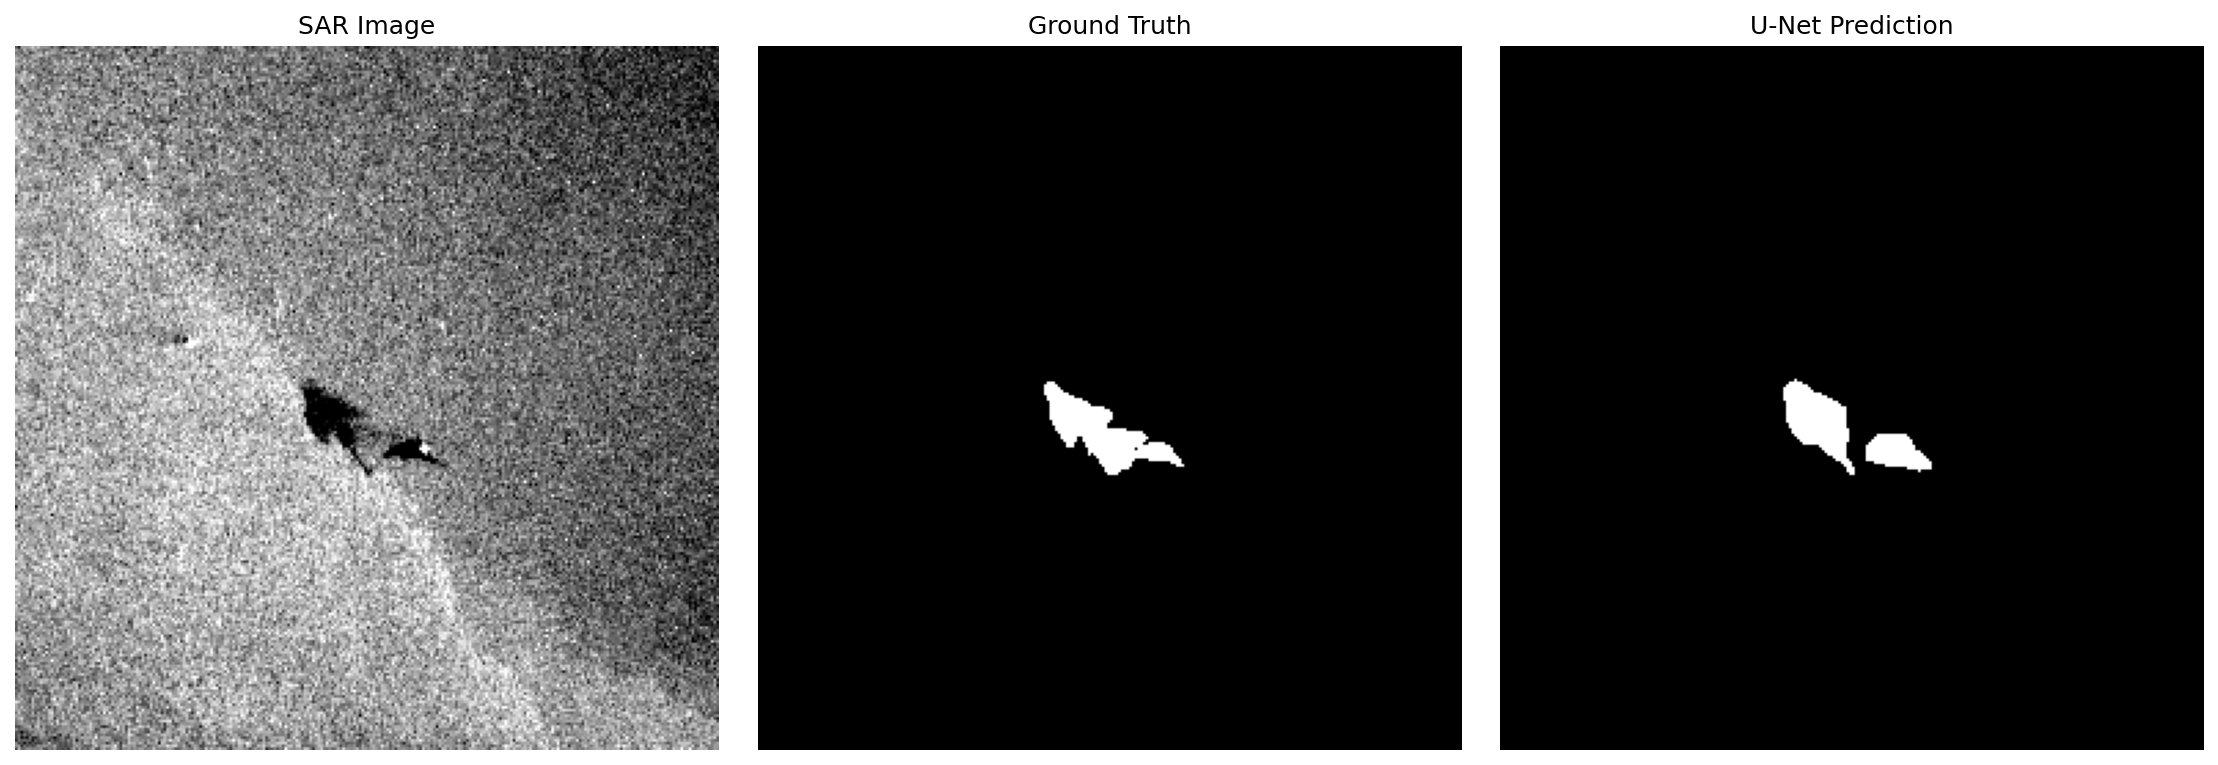

In [33]:
from IPython.display import Image, display

display(
    Image(
        filename="oil_spill_detection/predictions/prediction_6.png"
    )
)

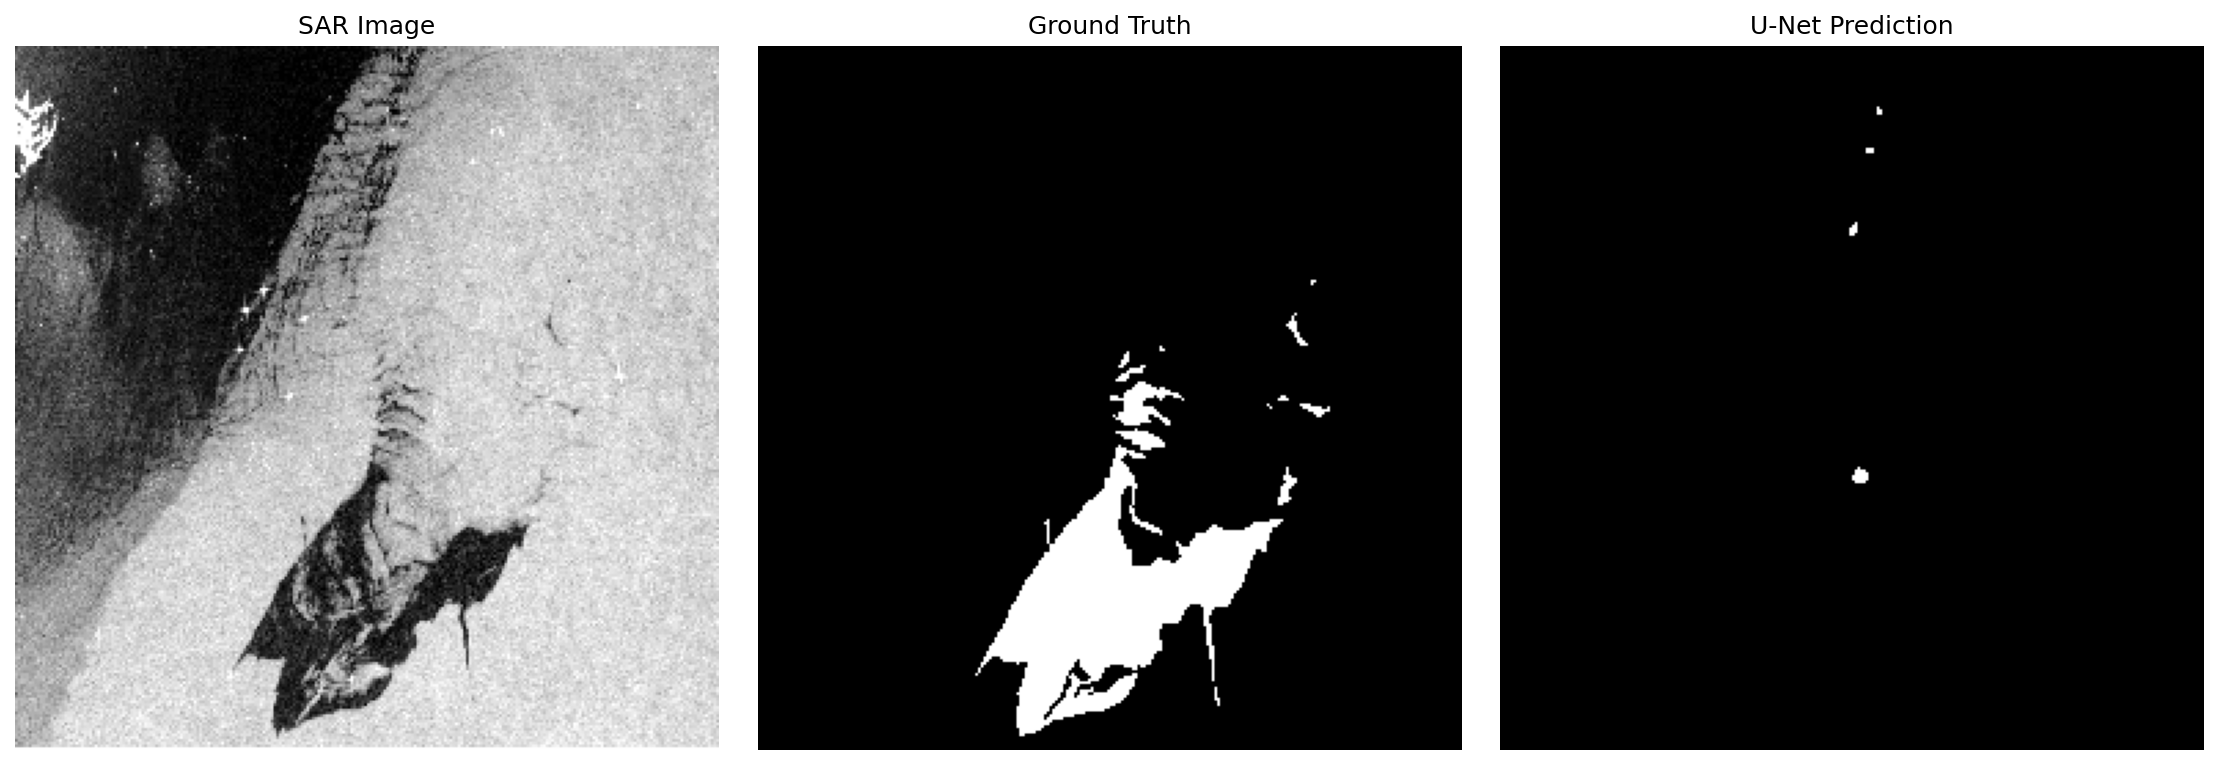

In [34]:
display(
    Image(
        filename="oil_spill_detection/predictions/prediction_4.png"
    )
)